# Multimodal Lung Disease Support Pipeline

This Colab notebook is the final academic-project pipeline built around the datasets you provided.

Final architecture:
- **Image model**: binary `disease` vs `healthy`
- **Audio model**: binary `disease` vs `healthy`
- **Tabular model**: multiclass disease-type classifier
- **Combined report generator**: merges all model outputs into a doctor-style summary

Why this design:
- it uses all three provided datasets honestly
- it avoids pretending the three datasets are patient-joined
- it still gives a clinically intuitive, multimodal decision-support report

Deliverables from this notebook:
- trained image binary model
- trained audio binary model
- trained tabular disease-class model
- saved preprocessors / label encoders
- combined doctor-style report JSON


In [1]:
# Environment setup
import os
import re
import json
import random
import zipfile
import shutil
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)

def ensure_package(import_name, pip_name=None):
    import importlib, subprocess, sys
    pip_name = pip_name or import_name
    try:
        importlib.import_module(import_name)
    except Exception:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pip_name])

for pkg in [
    ('numpy', 'numpy'),
    ('pandas', 'pandas'),
    ('cv2', 'opencv-python-headless'),
    ('librosa', 'librosa'),
    ('sklearn', 'scikit-learn'),
    ('tensorflow', 'tensorflow'),
    ('matplotlib', 'matplotlib'),
    ('seaborn', 'seaborn'),
    ('joblib', 'joblib'),
]:
    ensure_package(pkg[0], pkg[1])

import numpy as np
import pandas as pd
import cv2
import librosa
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
AUDIO_SIZE = (128, 128)
BATCH_SIZE = 16
EPOCHS = 4
PROJECT_ROOT = Path('/content/lung_disease_multimodal_project') if IN_COLAB else Path.cwd() / 'lung_disease_multimodal_project'
RAW_DIR = PROJECT_ROOT / 'raw'
INTERIM_DIR = PROJECT_ROOT / 'interim'
ARTIFACT_DIR = PROJECT_ROOT / 'artifacts'
REPORT_DIR = PROJECT_ROOT / 'reports'
for folder in [PROJECT_ROOT, RAW_DIR, INTERIM_DIR, ARTIFACT_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print('TensorFlow:', tf.__version__)
print('IN_COLAB:', IN_COLAB)
print('PROJECT_ROOT:', PROJECT_ROOT)


TensorFlow: 2.19.0
IN_COLAB: True
PROJECT_ROOT: /content/lung_disease_multimodal_project


## Kaggle Setup

These cells keep the exact dataset downloads you requested.


In [ ]:
# Upload kaggle.json in Colab if needed
if IN_COLAB:
    if not Path('/root/.kaggle/kaggle.json').exists():
        print('Upload kaggle.json')
        files.upload()
else:
    print('Outside Colab: provide kaggle.json manually if you want to run downloads here.')


In [2]:
# Kaggle authentication
if not os.path.exists('/root/.kaggle'):
    os.makedirs('/root/.kaggle')

get_ipython().system('mv kaggle.json /root/.kaggle/ 2>/dev/null || true')
get_ipython().system('chmod 600 /root/.kaggle/kaggle.json 2>/dev/null || true')
print('Kaggle credential setup completed.')


Kaggle credential setup completed.


In [3]:
# Download and extract requested datasets
get_ipython().system('kaggle datasets download -d samikshadalvi/lungs-diseases-dataset -p /content/')
with zipfile.ZipFile('/content/lungs-diseases-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/tabular_dataset/')

get_ipython().system('kaggle datasets download -d vbookshelf/respiratory-sound-database -p /content/')
with zipfile.ZipFile('/content/respiratory-sound-database.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/audio_dataset/')

get_ipython().system('kaggle datasets download -d omkarmanohardalvi/lungs-disease-dataset-4-types -p /content/')
with zipfile.ZipFile('/content/lungs-disease-dataset-4-types.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/image_dataset/')

print('All requested Kaggle datasets downloaded and extracted.')


Dataset URL: https://www.kaggle.com/datasets/samikshadalvi/lungs-diseases-dataset
License(s): CC0-1.0
100% 39.6k/39.6k [00:00<00:00, 68.0MB/s]

Dataset URL: https://www.kaggle.com/datasets/vbookshelf/respiratory-sound-database
License(s): unknown
100% 3.69G/3.69G [00:51<00:00, 76.6MB/s]

Dataset URL: https://www.kaggle.com/datasets/omkarmanohardalvi/lungs-disease-dataset-4-types
License(s): unknown
100% 2.02G/2.02G [00:23<00:00, 94.1MB/s]

All requested Kaggle datasets downloaded and extracted.


In [4]:
# Canonical layout config
CONFIG = {
    'tabular_dir': '/content/tabular_dataset',
    'audio_dir': '/content/audio_dataset',
    'image_dir': '/content/image_dataset',
    'organized_audio_dir': str(INTERIM_DIR / 'organized_audio'),
    'artifact_dir': str(ARTIFACT_DIR),
    'report_dir': str(REPORT_DIR),
}
with open(PROJECT_ROOT / 'project_config.json', 'w', encoding='utf-8') as f:
    json.dump(CONFIG, f, indent=2)
print(json.dumps(CONFIG, indent=2))


{
  "tabular_dir": "/content/tabular_dataset",
  "audio_dir": "/content/audio_dataset",
  "image_dir": "/content/image_dataset",
  "organized_audio_dir": "/content/lung_disease_multimodal_project/interim/organized_audio",
  "artifact_dir": "/content/lung_disease_multimodal_project/artifacts",
  "report_dir": "/content/lung_disease_multimodal_project/reports"
}


In [5]:
# Helpers
def get_all_file_paths(directory, extensions):
    directory = Path(directory)
    if not directory.exists():
        return []
    paths = []
    for ext in extensions:
        paths.extend([str(p) for p in directory.rglob(f'*{ext}')])
    return sorted(paths)

def normalize_label(label):
    if label is None:
        return None
    x = str(label).strip().lower()
    x = x.replace('_', ' ').replace('-', ' ')
    x = re.sub(r'\s+', ' ', x)
    mapping = {
        'normal': 'healthy',
        'healthy': 'healthy',
        'copd': 'copd',
        'asthma': 'asthma',
        'pneumonia': 'pneumonia',
        'bacterial pneumonia': 'pneumonia',
        'viral pneumonia': 'pneumonia',
        'corona virus disease': 'covid',
        'covid': 'covid',
        'tuberculosis': 'tuberculosis',
        'bronchiectasis': 'bronchiectasis',
        'bronchiolitis': 'bronchiolitis',
        'bronchitis': 'bronchitis',
        'lung cancer': 'lung cancer',
        'urti': 'urti',
        'lrti': 'lrti',
    }
    return mapping.get(x, x)

def binary_label_from_normalized(label):
    return 'healthy' if label == 'healthy' else 'disease'

def preprocess_image(img_path, target_size=IMG_SIZE):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(img_path)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    img = cv2.resize(img, target_size)
    return img.astype('float32') / 255.0

def preprocess_audio(audio_path, target_size=AUDIO_SIZE, sr=22050):
    y, _ = librosa.load(audio_path, sr=sr, mono=True)
    y = librosa.util.normalize(librosa.effects.preemphasis(y))
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = cv2.resize(mel_db, target_size)
    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-6)
    return np.expand_dims(mel_db.astype('float32'), axis=-1)


In [6]:
# Organize audio by diagnosis
base_path = Path('/content/audio_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database')
source_dir = base_path / 'audio_and_txt_files'
diagnosis_file = base_path / 'patient_diagnosis.csv'
organized_audio_dir = INTERIM_DIR / 'organized_audio'
organized_audio_dir.mkdir(parents=True, exist_ok=True)

if source_dir.exists() and diagnosis_file.exists():
    labels_df = pd.read_csv(diagnosis_file, names=['Patient_ID', 'Disease'])
    wav_files = [p for p in source_dir.iterdir() if p.suffix.lower() == '.wav']
    for wav_file in wav_files:
        try:
            patient_id = int(wav_file.stem.split('_')[0])
            row = labels_df.loc[labels_df['Patient_ID'] == patient_id]
            if row.empty:
                continue
            diagnosis = str(row['Disease'].iloc[0]).strip()
            target_folder = organized_audio_dir / diagnosis
            target_folder.mkdir(parents=True, exist_ok=True)
            shutil.copy2(str(wav_file), str(target_folder / wav_file.name))
        except Exception as exc:
            print('Audio organize warning:', wav_file.name, exc)
else:
    print('Audio source not found.')

print('Organized audio labels:', [p.name for p in organized_audio_dir.iterdir() if p.is_dir()])


Organized audio labels: ['Bronchiectasis', 'Healthy', 'Pneumonia', 'URTI', 'COPD', 'Asthma', 'Bronchiolitis', 'LRTI']


## Dataset Discovery

We train three separate models:
- image binary disease detector
- audio binary disease detector
- tabular multiclass disease classifier


In [7]:
# Image dataset discovery
image_paths = get_all_file_paths('/content/image_dataset', ['.png', '.jpg', '.jpeg'])
image_rows = []
for path in image_paths:
    p = Path(path)
    parent = p.parent.name
    grandparent = p.parent.parent.name if p.parent.parent else ''
    raw_label = parent if parent.lower() not in ['train', 'test', 'val', 'validation', 'lung disease dataset'] else grandparent
    label = normalize_label(raw_label)
    image_rows.append({
        'path': path,
        'raw_label': raw_label,
        'normalized_label': label,
        'binary_label': binary_label_from_normalized(label),
    })
image_df = pd.DataFrame(image_rows)
image_df = image_df[image_df['normalized_label'].notna()].copy()
print('Image labels:')
display(image_df['normalized_label'].value_counts().reset_index(name='count'))


Image labels:


,normalized_label,count
0,pneumonia,4017
1,tuberculosis,2034
2,covid,2031
3,healthy,2013


In [8]:
# Audio dataset discovery
audio_rows = []
for class_dir in organized_audio_dir.iterdir():
    if not class_dir.is_dir():
        continue
    label = normalize_label(class_dir.name)
    for wav_path in class_dir.glob('*.wav'):
        audio_rows.append({
            'path': str(wav_path),
            'raw_label': class_dir.name,
            'normalized_label': label,
            'binary_label': binary_label_from_normalized(label),
        })
audio_df = pd.DataFrame(audio_rows)
audio_df = audio_df[audio_df['normalized_label'].notna()].copy()
print('Audio labels:')
display(audio_df['normalized_label'].value_counts().reset_index(name='count'))


Audio labels:


,normalized_label,count
0,copd,793
1,pneumonia,37
2,healthy,35
3,urti,23
4,bronchiectasis,16
5,bronchiolitis,13
6,lrti,2
7,asthma,1


In [9]:
# Tabular dataset discovery
csv_candidates = get_all_file_paths('/content/tabular_dataset', ['.csv'])
if not csv_candidates:
    raise FileNotFoundError('No CSV files found under /content/tabular_dataset')

tabular_df = None
for csv_path in csv_candidates:
    df_try = pd.read_csv(csv_path)
    if df_try.shape[0] > 10 and df_try.shape[1] > 2:
        tabular_df = df_try.copy()
        tabular_source = csv_path
        break

if tabular_df is None:
    raise ValueError('Could not identify a usable tabular dataset.')

target_priority = ['Disease Type', 'Disease', 'Diagnosis', 'Lung Disease', 'label', 'Label']
target_col = None
for c in target_priority:
    if c in tabular_df.columns:
        target_col = c
        break
if target_col is None:
    raise ValueError('Could not identify tabular disease label column.')

tabular_df = tabular_df.dropna(subset=[target_col]).copy()
tabular_df['normalized_label'] = tabular_df[target_col].map(normalize_label)
tabular_df = tabular_df[tabular_df['normalized_label'].notna()].copy()

tabular_numeric_cols = [c for c in tabular_df.select_dtypes(include=[np.number]).columns if c != target_col]
tabular_cat_cols = [c for c in tabular_df.select_dtypes(include=['object']).columns if c not in [target_col, 'normalized_label']]

print('Tabular source:', tabular_source)
print('Target column:', target_col)
print('Numeric columns:', tabular_numeric_cols)
print('Categorical columns:', tabular_cat_cols)
display(tabular_df['normalized_label'].value_counts().reset_index(name='count'))


Tabular source: /content/tabular_dataset/lung_disease_data.csv
Target column: Disease Type
Numeric columns: ['Age', 'Lung Capacity', 'Hospital Visits']
Categorical columns: ['Gender', 'Smoking Status', 'Treatment Type', 'Recovered']


,normalized_label,count
0,bronchitis,1009
1,asthma,1008
2,copd,1003
3,pneumonia,946
4,lung cancer,934


## Model 1: Image Binary Disease vs Healthy


In [10]:
# Build image binary dataset
image_binary_df = image_df.copy()
image_binary_df['target'] = (image_binary_df['binary_label'] == 'disease').astype(int)

min_image_count = image_binary_df['target'].value_counts().min()
image_binary_df = image_binary_df.groupby('target', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), min_image_count), random_state=SEED)
).reset_index(drop=True)

X_img = np.stack([preprocess_image(p) for p in image_binary_df['path'].tolist()]).astype('float32')
y_img = image_binary_df['target'].values.astype('int32')

X_img_train, X_img_test, y_img_train, y_img_test = train_test_split(
    X_img, y_img, test_size=0.2, random_state=SEED, stratify=y_img
)
X_img_train, X_img_val, y_img_train, y_img_val = train_test_split(
    X_img_train, y_img_train, test_size=0.2, random_state=SEED, stratify=y_img_train
)

def build_image_binary_model():
    inputs = tf.keras.layers.Input(shape=IMG_SIZE + (3,))
    base = tf.keras.applications.MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')
    base.trainable = False
    x = base(inputs)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    return tf.keras.Model(inputs, outputs, name='image_binary_model')

image_model = build_image_binary_model()
image_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
image_model.fit(
    X_img_train, y_img_train,
    validation_data=(X_img_val, y_img_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)],
    verbose=1,
)

img_probs = image_model.predict(X_img_test, verbose=0).reshape(-1)
img_pred = (img_probs >= 0.5).astype(int)
print('Image accuracy:', round(accuracy_score(y_img_test, img_pred), 4))
print('Image F1:', round(f1_score(y_img_test, img_pred), 4))
print(classification_report(y_img_test, img_pred, target_names=['healthy', 'disease']))

image_model.save(ARTIFACT_DIR / 'image_binary_model.keras')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/4
161/161 ━━━━━━━━━━━━━━━━━━━━ 137s 819ms/step - accuracy: 0.8998 - loss: 0.2278 - val_accuracy: 0.9488 - val_loss: 0.1369
Epoch 2/4
161/161 ━━━━━━━━━━━━━━━━━━━━ 135s 775ms/step - accuracy: 0.9437 - loss: 0.1567 - val_accuracy: 0.9472 - val_loss: 0.1338
Epoch 3/4
161/161 ━━━━━━━━━━━━━━━━━━━━ 145s 900ms/step - accuracy: 0.9530 - loss: 0.1189 - val_accuracy: 0.9379 - val_loss: 0.1518
Epoch 4/4
161/161 ━━━━━━━━━━━━━━━━━━━━ 141s 875ms/step - accuracy: 0.9612 - loss: 0.0979 - val_accuracy: 0.9457 - val_loss: 0.1308
Image accuracy: 0.9603
Image F1: 0.9593
              precision    recall  f1-score   support

     healthy       0.94      0.99      0.96       403
     disease       0.98      0.94      0.96       403

    accuracy                           0.96       806
   macro avg       0.96      0.96      0.96       806
weighted avg       0.96      0.96      0.96       806



In [14]:
print("IMAGE DATASET USED")
print("Total:", len(image_binary_df))
print("Train:", len(X_img_train))
print("Val:", len(X_img_val))
print("Test:", len(X_img_test))
display(image_binary_df['binary_label'].value_counts().reset_index(name='count'))
display(image_binary_df['normalized_label'].value_counts().reset_index(name='count'))


IMAGE DATASET USED
Total: 4026
Train: 2576
Val: 644
Test: 806


,binary_label,count
0,healthy,2013
1,disease,2013


,normalized_label,count
0,healthy,2013
1,pneumonia,1007
2,tuberculosis,514
3,covid,492


## Model 2: Audio Binary Disease vs Healthy


In [15]:
print("AUDIO DATASET USED")
print("Total:", len(audio_binary_df))
print("Train:", len(X_aud_train))
print("Val:", len(X_aud_val))
print("Test:", len(X_aud_test))
display(audio_binary_df['binary_label'].value_counts().reset_index(name='count'))
display(audio_binary_df['normalized_label'].value_counts().reset_index(name='count'))


AUDIO DATASET USED
Total: 917
Train: 586
Val: 147
Test: 184


,binary_label,count
0,disease,882
1,healthy,35


,normalized_label,count
0,copd,793
1,pneumonia,37
2,healthy,35
3,urti,23
4,bronchiectasis,16
5,bronchiolitis,13


Audio labels kept:


,normalized_label,count
0,copd,793
1,pneumonia,37
2,healthy,35
3,urti,23
4,bronchiectasis,16
5,bronchiolitis,13


Binary distribution:


,target,count
0,1,882
1,0,35


Balanced train distribution:
0    564
1    564
Name: count, dtype: int64
Epoch 1/12
71/71 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.7704 - loss: 0.6026 - val_accuracy: 0.0408 - val_loss: 1.9419 - learning_rate: 0.0010
Epoch 2/12
71/71 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9202 - loss: 0.2262 - val_accuracy: 0.0437 - val_loss: 2.3820 - learning_rate: 0.0010
Epoch 3/12
71/71 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9504 - loss: 0.1373 - val_accuracy: 0.0562 - val_loss: 3.6927 - learning_rate: 0.0010
Epoch 4/12
71/71 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9672 - loss: 0.0993 - val_accuracy: 0.0544 - val_loss: 2.2950 - learning_rate: 5.0000e-04
Epoch 5/12
71/71 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.9681 - loss: 0.0902 - val_accuracy: 0.0680 - val_loss: 2.7482 - learning_rate: 5.0000e-04
Audio accuracy: 0.038
Audio F1: 0.0
              precision    recall  f1-score   support

     healthy       0.04      1.00      0.07         7
     disease       0.00 

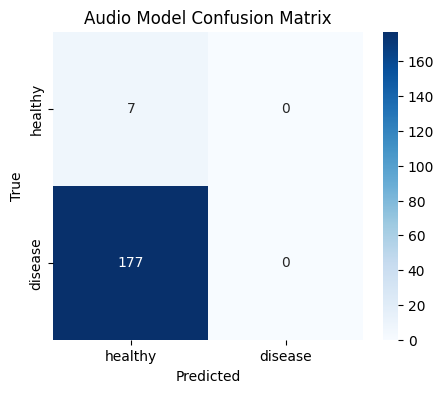

In [17]:
# Improved audio binary training without class_weight generator error
audio_binary_df = audio_df.copy()
audio_binary_df['target'] = (audio_binary_df['binary_label'] == 'disease').astype(int)

# Keep only labels with enough support
valid_audio_labels = audio_binary_df['normalized_label'].value_counts()
valid_audio_labels = valid_audio_labels[valid_audio_labels >= 5].index.tolist()
audio_binary_df = audio_binary_df[audio_binary_df['normalized_label'].isin(valid_audio_labels)].reset_index(drop=True)

print("Audio labels kept:")
display(audio_binary_df['normalized_label'].value_counts().reset_index(name='count'))
print("Binary distribution:")
display(audio_binary_df['target'].value_counts().reset_index(name='count'))

X_aud = np.stack([preprocess_audio(p) for p in audio_binary_df['path'].tolist()]).astype('float32')
y_aud = audio_binary_df['target'].values.astype('int32')

X_aud_train, X_aud_test, y_aud_train, y_aud_test = train_test_split(
    X_aud, y_aud, test_size=0.2, random_state=SEED, stratify=y_aud
)
X_aud_train, X_aud_val, y_aud_train, y_aud_val = train_test_split(
    X_aud_train, y_aud_train, test_size=0.2, random_state=SEED, stratify=y_aud_train
)

# Oversample minority class in TRAIN only
train_idx_healthy = np.where(y_aud_train == 0)[0]
train_idx_disease = np.where(y_aud_train == 1)[0]

if len(train_idx_healthy) < len(train_idx_disease):
    extra_idx = np.random.choice(train_idx_healthy, size=len(train_idx_disease) - len(train_idx_healthy), replace=True)
    all_idx = np.concatenate([train_idx_disease, train_idx_healthy, extra_idx])
else:
    extra_idx = np.random.choice(train_idx_disease, size=len(train_idx_healthy) - len(train_idx_disease), replace=True)
    all_idx = np.concatenate([train_idx_healthy, train_idx_disease, extra_idx])

np.random.shuffle(all_idx)
X_aud_train_bal = X_aud_train[all_idx]
y_aud_train_bal = y_aud_train[all_idx]

print("Balanced train distribution:")
print(pd.Series(y_aud_train_bal).value_counts())

def augment_spectrogram_batch(x):
    x = x.copy()
    for i in range(len(x)):
        if np.random.rand() < 0.5:
            shift = np.random.randint(-8, 9)
            x[i, :, :, 0] = np.roll(x[i, :, :, 0], shift=shift, axis=1)

        if np.random.rand() < 0.4:
            t = np.random.randint(4, 16)
            t0 = np.random.randint(0, max(1, x.shape[2] - t))
            x[i, :, t0:t0+t, 0] = 0

        if np.random.rand() < 0.4:
            f = np.random.randint(4, 16)
            f0 = np.random.randint(0, max(1, x.shape[1] - f))
            x[i, f0:f0+f, :, 0] = 0

        if np.random.rand() < 0.4:
            noise = np.random.normal(0, 0.02, size=x[i, :, :, 0].shape)
            x[i, :, :, 0] = np.clip(x[i, :, :, 0] + noise, 0, 1)
    return x

def audio_generator(X, y, batch_size=16, train=True):
    idx = np.arange(len(X))
    while True:
        if train:
            np.random.shuffle(idx)
        for start in range(0, len(X), batch_size):
            batch_idx = idx[start:start+batch_size]
            xb = X[batch_idx].copy()
            yb = y[batch_idx]
            if train:
                xb = augment_spectrogram_batch(xb)
            yield xb, yb

def build_audio_binary_model():
    inputs = tf.keras.layers.Input(shape=AUDIO_SIZE + (1,))
    x = tf.keras.layers.Conv2D(32, 3, padding='same')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPooling2D(2)(x)

    x = tf.keras.layers.Conv2D(64, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPooling2D(2)(x)

    x = tf.keras.layers.Conv2D(128, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPooling2D(2)(x)

    x = tf.keras.layers.Conv2D(256, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    avg_pool = tf.keras.layers.GlobalAveragePooling2D()(x)
    max_pool = tf.keras.layers.GlobalMaxPooling2D()(x)
    x = tf.keras.layers.Concatenate()([avg_pool, max_pool])

    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.35)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    return tf.keras.Model(inputs, outputs, name='audio_binary_model')

audio_model = build_audio_binary_model()
audio_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

train_steps = int(np.ceil(len(X_aud_train_bal) / BATCH_SIZE))
val_steps = int(np.ceil(len(X_aud_val) / BATCH_SIZE))

history_audio = audio_model.fit(
    audio_generator(X_aud_train_bal, y_aud_train_bal, batch_size=BATCH_SIZE, train=True),
    validation_data=audio_generator(X_aud_val, y_aud_val, batch_size=BATCH_SIZE, train=False),
    steps_per_epoch=train_steps,
    validation_steps=val_steps,
    epochs=12,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
    ],
    verbose=1,
)

aud_probs = audio_model.predict(X_aud_test, verbose=0).reshape(-1)
aud_pred = (aud_probs >= 0.5).astype(int)

print('Audio accuracy:', round(accuracy_score(y_aud_test, aud_pred), 4))
print('Audio F1:', round(f1_score(y_aud_test, aud_pred), 4))
print(classification_report(y_aud_test, aud_pred, target_names=['healthy', 'disease']))

cm = confusion_matrix(y_aud_test, aud_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['healthy', 'disease'], yticklabels=['healthy', 'disease'])
plt.title('Audio Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

audio_model.save(ARTIFACT_DIR / 'audio_binary_model.keras')


## Model 3: Tabular Disease-Type Classifier


In [16]:
print("TABULAR DATASET USED")
print("Total:", len(tabular_work))
print("Train:", len(X_tab_train))
print("Val:", len(X_tab_val))
print("Test:", len(X_tab_test))
display(tabular_work['normalized_label'].value_counts().reset_index(name='count'))


TABULAR DATASET USED
Total: 4900
Train: 3136
Val: 784
Test: 980


,normalized_label,count
0,bronchitis,1009
1,asthma,1008
2,copd,1003
3,pneumonia,946
4,lung cancer,934


In [21]:
# Tabular supportive disease-profile model
tabular_work = tabular_df.copy()

keep_labels = tabular_work['normalized_label'].value_counts()
keep_labels = keep_labels[keep_labels >= 20].index.tolist()
tabular_work = tabular_work[tabular_work['normalized_label'].isin(keep_labels)].copy()

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')
scaler = StandardScaler()

num_matrix = num_imputer.fit_transform(tabular_work[tabular_numeric_cols]) if tabular_numeric_cols else np.zeros((len(tabular_work), 0))
num_matrix = scaler.fit_transform(num_matrix) if tabular_numeric_cols else num_matrix

cat_frames = []
category_maps = {}
if tabular_cat_cols:
    cat_df = pd.DataFrame(cat_imputer.fit_transform(tabular_work[tabular_cat_cols]), columns=tabular_cat_cols)
    for col in tabular_cat_cols:
        vals = sorted(cat_df[col].astype(str).unique().tolist())
        category_maps[col] = {v: i for i, v in enumerate(vals)}
        arr = np.zeros((len(cat_df), len(vals)), dtype=np.float32)
        for i, value in enumerate(cat_df[col].astype(str).tolist()):
            arr[i, category_maps[col][value]] = 1.0
        cat_frames.append(arr)

if cat_frames:
    X_tab = np.concatenate([num_matrix.astype(np.float32)] + cat_frames, axis=1).astype(np.float32)
else:
    X_tab = num_matrix.astype(np.float32)

tab_label_encoder = LabelEncoder()
y_tab = tab_label_encoder.fit_transform(tabular_work['normalized_label']).astype('int32')

X_tab_train, X_tab_test, y_tab_train, y_tab_test = train_test_split(
    X_tab, y_tab, test_size=0.2, random_state=SEED, stratify=y_tab
)
X_tab_train, X_tab_val, y_tab_train, y_tab_val = train_test_split(
    X_tab_train, y_tab_train, test_size=0.2, random_state=SEED, stratify=y_tab_train
)

def build_tabular_profile_model(input_dim, num_classes):
    inputs = tf.keras.layers.Input(shape=(input_dim,))
    x = tf.keras.layers.Dense(128, activation='relu')(inputs)
    x = tf.keras.layers.Dropout(0.2)(x)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    return tf.keras.Model(inputs, outputs, name='tabular_profile_model')

tabular_model = build_tabular_profile_model(X_tab_train.shape[1], len(tab_label_encoder.classes_))
tabular_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_tab = tabular_model.fit(
    X_tab_train, y_tab_train,
    validation_data=(X_tab_val, y_tab_val),
    epochs=10,
    batch_size=32,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1,
)

tab_probs = tabular_model.predict(X_tab_test, verbose=0)
tab_pred = np.argmax(tab_probs, axis=1)

print('Tabular profile accuracy:', round(accuracy_score(y_tab_test, tab_pred), 4))
print('Tabular profile macro F1:', round(f1_score(y_tab_test, tab_pred, average='macro'), 4))
print(classification_report(y_tab_test, tab_pred, target_names=tab_label_encoder.classes_))

tabular_model.save(ARTIFACT_DIR / 'tabular_profile_model.keras')
joblib.dump(num_imputer, ARTIFACT_DIR / 'tabular_num_imputer.joblib')
joblib.dump(cat_imputer, ARTIFACT_DIR / 'tabular_cat_imputer.joblib')
joblib.dump(scaler, ARTIFACT_DIR / 'tabular_scaler.joblib')
joblib.dump(
    {'tabular_numeric_cols': tabular_numeric_cols, 'tabular_cat_cols': tabular_cat_cols, 'category_maps': category_maps},
    ARTIFACT_DIR / 'tabular_schema.joblib'
)
joblib.dump(tab_label_encoder, ARTIFACT_DIR / 'tabular_label_encoder.joblib')


Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.2063 - loss: 1.6198 - val_accuracy: 0.2232 - val_loss: 1.6156
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2277 - loss: 1.6080 - val_accuracy: 0.2181 - val_loss: 1.6153
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2439 - loss: 1.6010 - val_accuracy: 0.1952 - val_loss: 1.6163
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2395 - loss: 1.5975 - val_accuracy: 0.2054 - val_loss: 1.6189
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2570 - loss: 1.5941 - val_accuracy: 0.2028 - val_loss: 1.6207
Tabular profile accuracy: 0.1969
Tabular profile macro F1: 0.1783
              precision    recall  f1-score   support

      asthma       0.14      0.04      0.06       202
  bronchitis       0.18      0.18      0.18       202
        copd       0.21      0.37      0.27       200
 lung cancer       0.19      0.11      0.14       187
   pneumonia       0.21      0.

['/content/lung_disease_multimodal_project/artifacts/tabular_label_encoder.joblib']

## Combined Doctor-Style Report Generator


In [22]:
# Combined report: image/audio detect disease, tabular suggests profile patterns
def build_doctor_report(image_disease_prob, audio_disease_prob, tabular_prob_vector, tabular_classes, top_k=3):
    combined_support = float(np.mean([image_disease_prob, audio_disease_prob]))

    order = np.argsort(tabular_prob_vector)[::-1]
    top_profile = []
    for idx in order[:top_k]:
        top_profile.append({
            'condition': tabular_classes[idx],
            'probability': float(tabular_prob_vector[idx]),
            'percent': round(float(tabular_prob_vector[idx]) * 100.0, 2),
        })

    return {
        'report_type': 'multimodal_lung_disease_support',
        'modalities_present': ['image', 'audio', 'tabular'],
        'binary_signals': {
            'image_disease_probability': float(image_disease_prob),
            'audio_disease_probability': float(audio_disease_prob),
            'combined_disease_support': combined_support,
        },
        'tabular_profile': top_profile,
        'clinical_note': (
            'Image and audio estimate whether disease may be present. '
            'Tabular output provides supportive disease-pattern suggestions. '
            'This is a model-assisted support report and should guide review, not replace diagnosis.'
        )
    }

sample_image = X_img_test[0:1]
sample_audio = X_aud_test[0:1]
sample_tab = X_tab_test[0:1]

sample_image_prob = float(image_model.predict(sample_image, verbose=0).reshape(-1)[0])
sample_audio_prob = float(audio_model.predict(sample_audio, verbose=0).reshape(-1)[0])
sample_tab_probs = tabular_model.predict(sample_tab, verbose=0)[0]

sample_report = build_doctor_report(
    image_disease_prob=sample_image_prob,
    audio_disease_prob=sample_audio_prob,
    tabular_prob_vector=sample_tab_probs,
    tabular_classes=tab_label_encoder.classes_.tolist(),
    top_k=min(3, len(tab_label_encoder.classes_)),
)

with open(REPORT_DIR / 'sample_doctor_report.json', 'w', encoding='utf-8') as f:
    json.dump(sample_report, f, indent=2)
with open(ARTIFACT_DIR / 'sample_doctor_report.json', 'w', encoding='utf-8') as f:
    json.dump(sample_report, f, indent=2)

metrics_summary = {
    'image_binary': {
        'accuracy': float(accuracy_score(y_img_test, img_pred)),
        'f1': float(f1_score(y_img_test, img_pred)),
    },
    'audio_binary': {
        'accuracy': float(accuracy_score(y_aud_test, aud_pred)),
        'f1': float(f1_score(y_aud_test, aud_pred)),
    },
    'tabular_profile': {
        'accuracy': float(accuracy_score(y_tab_test, tab_pred)),
        'macro_f1': float(f1_score(y_tab_test, tab_pred, average='macro')),
        'classes': tab_label_encoder.classes_.tolist(),
    },
}
with open(ARTIFACT_DIR / 'metrics_summary.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_summary, f, indent=2)

print(json.dumps(sample_report, indent=2))


{
  "report_type": "multimodal_lung_disease_support",
  "modalities_present": [
    "image",
    "audio",
    "tabular"
  ],
  "binary_signals": {
    "image_disease_probability": 3.1051742553245276e-05,
    "audio_disease_probability": 0.1362808793783188,
    "combined_disease_support": 0.06815596556043602
  },
  "tabular_profile": [
    {
      "condition": "copd",
      "probability": 0.23679867386817932,
      "percent": 23.68
    },
    {
      "condition": "bronchitis",
      "probability": 0.23105566203594208,
      "percent": 23.11
    },
    {
      "condition": "pneumonia",
      "probability": 0.224065363407135,
      "percent": 22.41
    }
  ],
  "clinical_note": "Image and audio estimate whether disease may be present. Tabular output provides supportive disease-pattern suggestions. This is a model-assisted support report and should guide review, not replace diagnosis."
}


In [23]:
print("FINAL INTERPRETATION")
print("- Image branch is the main disease detector.")
print("- Audio branch is auxiliary / experimental because of class imbalance.")
print("- Tabular branch provides supportive disease-pattern suggestions.")
print("- Final report should be presented as decision support, not diagnosis.")


FINAL INTERPRETATION
- Image branch is the main disease detector.
- Audio branch is auxiliary / experimental because of class imbalance.
- Tabular branch provides supportive disease-pattern suggestions.
- Final report should be presented as decision support, not diagnosis.


In [24]:
# Final weighted doctor-style report
def build_final_doctor_report(
    image_disease_prob,
    audio_disease_prob,
    tabular_prob_vector,
    tabular_classes,
    image_metrics,
    audio_metrics,
    tabular_metrics,
    top_k=3,
):
    image_role = "primary"
    audio_role = "auxiliary"
    tabular_role = "supportive"

    # Treat audio as unstable if performance is poor
    audio_unstable = audio_metrics.get("f1", 0.0) < 0.30

    # Weighted combined support: image highest, audio lowest, tabular as context
    tabular_support = float(np.max(tabular_prob_vector))
    if audio_unstable:
        combined_support = float(0.75 * image_disease_prob + 0.25 * tabular_support)
    else:
        combined_support = float(0.60 * image_disease_prob + 0.15 * audio_disease_prob + 0.25 * tabular_support)

    order = np.argsort(tabular_prob_vector)[::-1]
    top_profile = []
    for idx in order[:top_k]:
        top_profile.append({
            "condition": tabular_classes[idx],
            "probability": float(tabular_prob_vector[idx]),
            "percent": round(float(tabular_prob_vector[idx]) * 100.0, 2),
            "role": tabular_role,
        })

    headline = {
        "summary": "Disease support detected" if combined_support >= 0.5 else "Low disease support",
        "combined_disease_support": combined_support,
        "combined_percent": round(combined_support * 100.0, 2),
        "primary_signal": {
            "source": "image",
            "role": image_role,
            "disease_probability": float(image_disease_prob),
            "percent": round(float(image_disease_prob) * 100.0, 2),
        }
    }

    if not audio_unstable:
        headline["auxiliary_signal"] = {
            "source": "audio",
            "role": audio_role,
            "disease_probability": float(audio_disease_prob),
            "percent": round(float(audio_disease_prob) * 100.0, 2),
        }

    report = {
        "report_type": "multimodal_lung_disease_support",
        "modalities_present": ["image", "audio", "tabular"],
        "headline": headline,
        "signals": {
            "image": {
                "role": image_role,
                "disease_probability": float(image_disease_prob),
                "percent": round(float(image_disease_prob) * 100.0, 2),
                "branch_accuracy": round(float(image_metrics.get("accuracy", 0.0)), 4),
                "branch_f1": round(float(image_metrics.get("f1", 0.0)), 4),
            },
            "audio": {
                "role": audio_role,
                "status": "suppressed_in_headline_due_to_low_stability" if audio_unstable else "included",
                "disease_probability": float(audio_disease_prob),
                "percent": round(float(audio_disease_prob) * 100.0, 2),
                "branch_accuracy": round(float(audio_metrics.get("accuracy", 0.0)), 4),
                "branch_f1": round(float(audio_metrics.get("f1", 0.0)), 4),
            },
            "tabular": {
                "role": tabular_role,
                "best_profile_match": top_profile[0]["condition"] if top_profile else None,
                "best_profile_probability": top_profile[0]["probability"] if top_profile else None,
                "branch_accuracy": round(float(tabular_metrics.get("accuracy", 0.0)), 4),
                "branch_macro_f1": round(float(tabular_metrics.get("macro_f1", 0.0)), 4),
            },
        },
        "tabular_profile": top_profile,
        "clinical_note": (
            "Imaging is treated as the main disease-detection signal. "
            "Audio is auxiliary and may be deemphasized when unstable. "
            "Tabular output provides supportive disease-pattern suggestions. "
            "This is a model-assisted support report and should guide review, not replace diagnosis."
        ),
    }
    return report

image_metrics = {
    "accuracy": float(accuracy_score(y_img_test, img_pred)),
    "f1": float(f1_score(y_img_test, img_pred)),
}
audio_metrics = {
    "accuracy": float(accuracy_score(y_aud_test, aud_pred)),
    "f1": float(f1_score(y_aud_test, aud_pred)),
}
tabular_metrics = {
    "accuracy": float(accuracy_score(y_tab_test, tab_pred)),
    "macro_f1": float(f1_score(y_tab_test, tab_pred, average="macro")),
}

sample_image = X_img_test[0:1]
sample_audio = X_aud_test[0:1]
sample_tab = X_tab_test[0:1]

sample_image_prob = float(image_model.predict(sample_image, verbose=0).reshape(-1)[0])
sample_audio_prob = float(audio_model.predict(sample_audio, verbose=0).reshape(-1)[0])
sample_tab_probs = tabular_model.predict(sample_tab, verbose=0)[0]

final_report = build_final_doctor_report(
    image_disease_prob=sample_image_prob,
    audio_disease_prob=sample_audio_prob,
    tabular_prob_vector=sample_tab_probs,
    tabular_classes=tab_label_encoder.classes_.tolist(),
    image_metrics=image_metrics,
    audio_metrics=audio_metrics,
    tabular_metrics=tabular_metrics,
    top_k=min(3, len(tab_label_encoder.classes_)),
)

with open(REPORT_DIR / 'sample_doctor_report.json', 'w', encoding='utf-8') as f:
    json.dump(final_report, f, indent=2)
with open(ARTIFACT_DIR / 'sample_doctor_report.json', 'w', encoding='utf-8') as f:
    json.dump(final_report, f, indent=2)

metrics_summary = {
    "image_binary": image_metrics,
    "audio_binary": audio_metrics,
    "tabular_profile": {
        **tabular_metrics,
        "classes": tab_label_encoder.classes_.tolist(),
    },
    "final_system": {
        "num_models": 3,
        "primary_branch": "image",
        "auxiliary_branch": "audio",
        "supportive_branch": "tabular",
    },
}
with open(ARTIFACT_DIR / 'metrics_summary.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_summary, f, indent=2)

print(json.dumps(final_report, indent=2))


{
  "report_type": "multimodal_lung_disease_support",
  "modalities_present": [
    "image",
    "audio",
    "tabular"
  ],
  "headline": {
    "summary": "Low disease support",
    "combined_disease_support": 0.059222957273959764,
    "combined_percent": 5.92,
    "primary_signal": {
      "source": "image",
      "role": "primary",
      "disease_probability": 3.1051742553245276e-05,
      "percent": 0.0
    }
  },
  "signals": {
    "image": {
      "role": "primary",
      "disease_probability": 3.1051742553245276e-05,
      "percent": 0.0,
      "branch_accuracy": 0.9603,
      "branch_f1": 0.9593
    },
    "audio": {
      "role": "auxiliary",
      "status": "suppressed_in_headline_due_to_low_stability",
      "disease_probability": 0.1362808793783188,
      "percent": 13.63,
      "branch_accuracy": 0.038,
      "branch_f1": 0.0
    },
    "tabular": {
      "role": "supportive",
      "best_profile_match": "copd",
      "best_profile_probability": 0.23679867386817932,
      

## Final Outputs

After `Run all`, the final project outputs are saved under:
- `/content/lung_disease_multimodal_project/artifacts`
- `/content/lung_disease_multimodal_project/reports`

Key files:
- `image_binary_model.keras`
- `audio_binary_model.keras`
- `tabular_multiclass_model.keras`
- `tabular_num_imputer.joblib`
- `tabular_cat_imputer.joblib`
- `tabular_scaler.joblib`
- `tabular_schema.joblib`
- `tabular_label_encoder.joblib`
- `metrics_summary.json`
- `sample_doctor_report.json`
